In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import keras.layers as tfl

from keras.utils import image_dataset_from_directory
from keras.layers import RandomFlip, RandomRotation

In [4]:
BATCH_SIZE = 32
IMG_SIZE = (160, 160)
directory = "dataset/"
train_dataset = image_dataset_from_directory(directory, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE, validation_split=0.2, subset='training', seed=42)

validation_dataset = image_dataset_from_directory(directory, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE, validation_split=0.2, subset='validation', seed=42)

Found 327 files belonging to 2 classes.
Using 262 files for training.


Found 327 files belonging to 2 classes.
Using 65 files for validation.


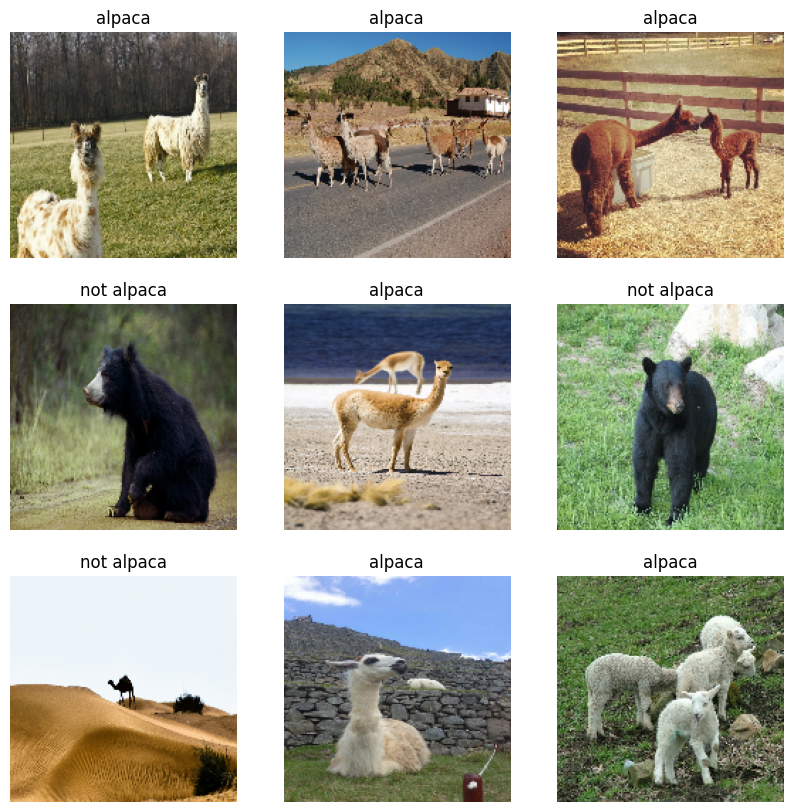

In [5]:
class_names = train_dataset.class_names

plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

data_augmenter

In [7]:
def data_augmenter():
    """
    Create a sequential model composed of 2 layers
    Returns:
        tf.keras.Sequential
    """

    data_augmentation = tf.keras.Sequential()
    data_augmentation.add(RandomFlip('horizontal'))
    data_augmentation.add(RandomRotation(0.2))

    return data_augmentation

In [8]:
augmenter = data_augmenter()

assert(augmenter.layers[0].name.startswith('random_flip')), "First layer must be RandomFlip"
assert augmenter.layers[0].mode == 'horizontal', "RandomFlip parameter must be horizontal"
assert(augmenter.layers[1].name.startswith('random_rotation')), "Second layer must be RandomRotation"
assert augmenter.layers[1].factor == (-0.2, 0.2), "Rotation factor must be 0.2"
print('\033[92mAll tests passed!')

All tests passed!


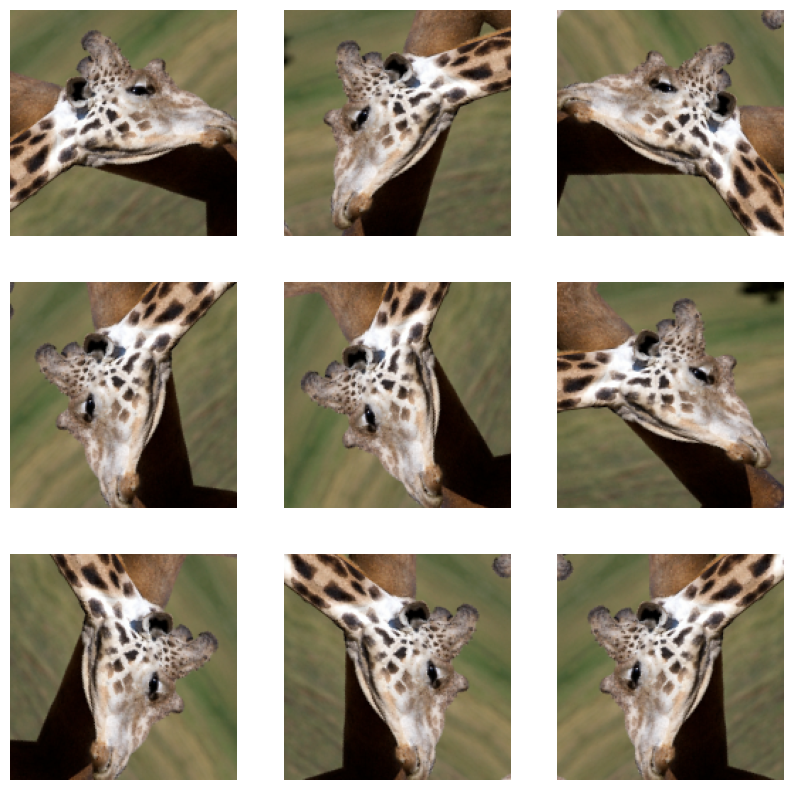

In [9]:
data_augmentation = data_augmenter()

for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

In [10]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Using MobileNetV2 for Transfer Learning

Inside a MobileNetV2 Convolutional Building Block

In [11]:

IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=True, weights='imagenet')

In [12]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [13]:
nb_layers = len(base_model.layers)
print(base_model.layers[nb_layers - 2].name)
print(base_model.layers[nb_layers - 1].name)

global_average_pooling2d
predictions


In [14]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 1000)


32 refers to the batch_size and 1000 refers to the 1000 classes the model was pretrained on

In [15]:
label_batch

<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0], dtype=int32)>

In [16]:
base_model.trainable = False
image_var = tf.Variable(image_batch)
pred = base_model(image_var)

tf.keras.applications.mobilenet_v2.decode_predictions(pred.numpy(), top=2)

[[('n04589890', 'window_screen', np.float32(0.42582113)),
  ('n02708093', 'analog_clock', np.float32(0.09275583))],
 [('n04589890', 'window_screen', np.float32(0.2398583)),
  ('n03887697', 'paper_towel', np.float32(0.14802672))],
 [('n04589890', 'window_screen', np.float32(0.7449452)),
  ('n03598930', 'jigsaw_puzzle', np.float32(0.021948697))],
 [('n04589890', 'window_screen', np.float32(0.33545953)),
  ('n03530642', 'honeycomb', np.float32(0.076289825))],
 [('n04589890', 'window_screen', np.float32(0.2732727)),
  ('n03733281', 'maze', np.float32(0.08846987))],
 [('n04589890', 'window_screen', np.float32(0.6745231)),
  ('n03530642', 'honeycomb', np.float32(0.07659909))],
 [('n04589890', 'window_screen', np.float32(0.7912843)),
  ('n04209239', 'shower_curtain', np.float32(0.092416994))],
 [('n04589890', 'window_screen', np.float32(0.16462962)),
  ('n03598930', 'jigsaw_puzzle', np.float32(0.08749185))],
 [('n03598930', 'jigsaw_puzzle', np.float32(0.37021372)),
  ('n04589890', 'window_scr

Layer Freezing with the Functional API

In [24]:
def alpaca_model(image_shape=IMG_SIZE, data_augmentation=data_augmenter()):
    """
    Define a tf.keras model for binary classification out of the MobileNetV2 model
    
    Arguments:
    image_shape -- image width and height
    data_augmentation -- data augmentation function

    Returns:
    tf.keras.model
    """

    input_shape = image_shape + (3,)

    base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)

    X = data_augmentation(inputs)
    X = preprocess_input(X)
    X = base_model(X, training=False)
    X = tfl.GlobalAveragePooling2D()(X)
    X = tfl.Dropout(0.2)(X)

    outputs = tfl.Dense(1)(X)

    model = tf.keras.Model(inputs, outputs)

    return model

In [25]:
model2 = alpaca_model(IMG_SIZE, data_augmentation)

In [29]:
from test_utils import summary, comparator

alpaca_summary = [['InputLayer', (None, 160, 160, 3), 0],
                  ['Sequential', (1, 160, 160, 3), 0],
                  ['Functional', (None, 5, 5, 1280), 2257984],
                  ['GlobalAveragePooling2D', (None, 1280), 0],
                  ['Dropout', (None, 1280), 0, 0.2],
                  ['Dense', (None, 1), 1281, 'linear']]

comparator(summary(model2), alpaca_summary)

for layer in summary(model2):
    print(layer)

All tests passed!
['InputLayer', (None, 160, 160, 3), 0]
['Sequential', (1, 160, 160, 3), 0]
['Functional', (None, 5, 5, 1280), 2257984]
['GlobalAveragePooling2D', (None, 1280), 0]
['Dropout', (None, 1280), 0, 0.2]
['Dense', (None, 1), 1281, 'linear']


In [37]:
base_learning_rate = 0.01
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate), loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])

In [38]:
initial_epochs = 15
history = model2.fit(train_dataset, validation_data=validation_dataset, epochs=initial_epochs)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9427 - loss: 0.1407 - val_accuracy: 0.9231 - val_loss: 0.2116
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 693ms/step - accuracy: 0.9427 - loss: 0.1577 - val_accuracy: 0.9538 - val_loss: 0.1036
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 634ms/step - accuracy: 0.9504 - loss: 0.1289 - val_accuracy: 0.9538 - val_loss: 0.1408
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 671ms/step - accuracy: 0.9084 - loss: 0.2024 - val_accuracy: 0.9385 - val_loss: 0.2038
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 629ms/step - accuracy: 0.9427 - loss: 0.1342 - val_accuracy: 0.9538 - val_loss: 0.1240
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 677ms/step - accuracy: 0.9427 - loss: 0.1434 - val_accuracy: 0.9385 - val_loss: 0.1124
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 660ms/step - accuracy: 0.9580 - loss: 0.1104 - val_accuracy: 0.9692 - val_loss: 0.1030
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 701ms/step - accuracy: 0.9656 - loss: 0.0842 - val_accuracy: 0.9692 - val_loss: 0

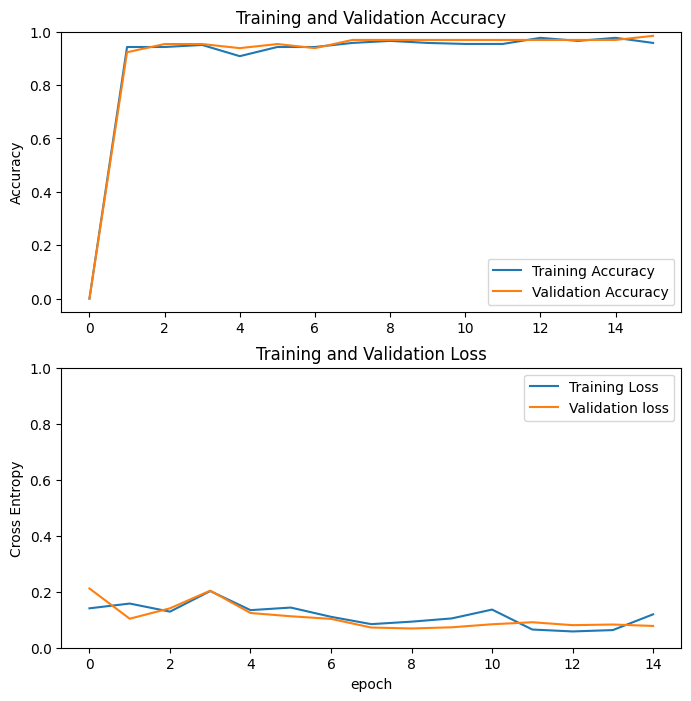

In [39]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [40]:
class_names

['alpaca', 'not alpaca']

Fine-Tuning the Model

In [41]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,538,984 (13.50 MB)

In [44]:
base_model.trainable = True

print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 126

"""
for layer in base_model.layers:
    if layer.name == 'block_16_expand:
        break
    layer.trainable = False
    print('Layer' + layer.name + ' frozen.')
"""

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = None

loss_function = tf.keras.losses.BinaryCrossentropy(from_logits=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=base_learning_rate*0.1)

metrics = ['accuracy']

model2.compile(loss=loss_function, optimizer=optimizer, metrics=metrics)

Number of layers in the base model:  156


In [47]:
assert type(loss_function) == tf.keras.losses.BinaryCrossentropy, "Not the correct layer"
assert loss_function.from_logits, "Use from_logits=True"
assert type(optimizer) == tf.keras.optimizers.Adam, "This is not an Adam optimizer"
assert optimizer.learning_rate == base_learning_rate / 10, "Wrong learning rate"
assert metrics[0] == 'accuracy', "Wrong metric"

print('\033[92mAll tests passed!')

All tests passed!


In [48]:
fine_tune_epochs = 5
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model2.fit(train_dataset, epochs=total_epochs, initial_epoch=history.epoch[-1], validation_data=validation_dataset)

Epoch 15/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 871ms/step - accuracy: 0.9542 - loss: 0.1048 - val_accuracy: 0.9692 - val_loss: 0.0732
Epoch 16/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 534ms/step - accuracy: 0.9809 - loss: 0.0729 - val_accuracy: 0.9692 - val_loss: 0.0725
Epoch 17/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 522ms/step - accuracy: 0.9733 - loss: 0.0737 - val_accuracy: 0.9692 - val_loss: 0.0713
Epoch 18/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 518ms/step - accuracy: 0.9771 - loss: 0.0700 - val_accuracy: 0.9692 - val_loss: 0.0695
Epoch 19/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 529ms/step - accuracy: 0.9542 - loss: 0.0942 - val_accuracy: 0.9692 - val_loss: 0.0693
Epoch 20/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 524ms/step - accuracy: 0.9695 - loss: 0.0682 - val_accuracy: 0.9692 - val_loss: 0.0756


In [49]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

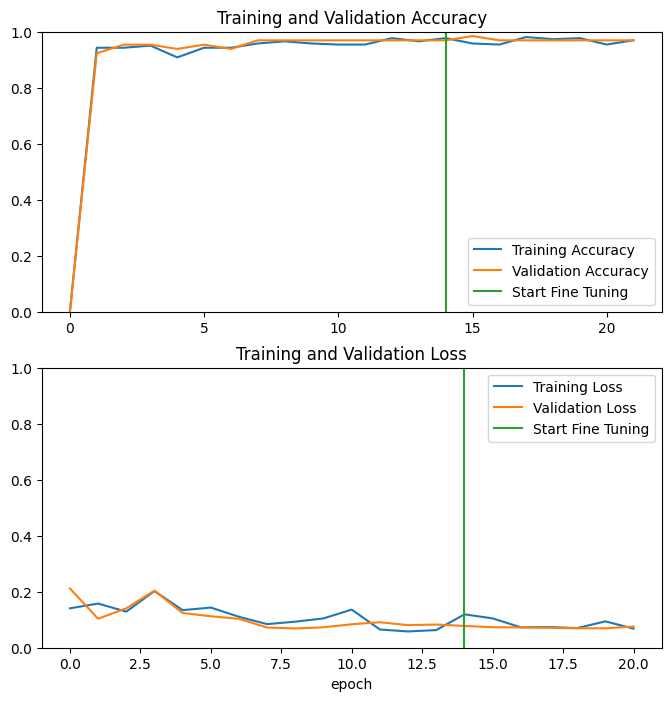

In [50]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()